In [ ]:
from pathlib import Path
import pandas as pd
import json
import pickle
import warnings
import shutil
import re
import hdf5storage

import importlib
import utils.functions as func
importlib.reload(func)
from utils.functions import *

from tqdm import tqdm
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

from applefy_extensions.contrast_curves import ContrastFast
from applefy.statistics import TTest, gaussian_sigma_2_fpf, fpf_2_gaussian_sigma
from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.utils.file_handling import save_as_fits
from applefy.utils.contrast_grid import compute_contrast_from_grid

from fours.utils.data_handling import read_fours_root_dir
from fours.utils.setups import contrast_grid_setup_1
from fours.detection_limits.applefy_wrapper import CADIDataReductionGPU, PCADataReductionGPU
from fours.detection_limits.applefy_wrapper import FourSDataReduction
from fours.models.psf_subtraction import FourS

# Load the Data

In [10]:
frame_rate = 1 / 400  # s
dit_science = 15e-3  # s
dit_psf = 0.5  # s
pixel_size = None  # arcsec
# LambdaD     = 4     #pixels
n_psf = round(dit_psf / dit_science)



sc_img_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy")
sc_img_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy")
psf_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_int_0.5ro_10ws.npy")
psf_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_pred_0.5ro_10ws.npy")


In [11]:
datasets = {
    "int": {
        "psf": psf_int,
        "sci_img": sc_img_int,
        "fwhm": calculate_fwhm(psf_int),
        "dit_psf": dit_psf,  # s of integration time
        "dit_science": dit_science,  # s = 10 phase screens at 0.001s each
    },
    "pred": {
        "psf": psf_pred,
        "sci_img": sc_img_pred,
        "fwhm": calculate_fwhm(psf_pred),
        "dit_psf": dit_psf,  # s of integration time
        "dit_science": dit_science,
    },
}

dataset = datasets['int']

FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 



# Run fake planet experiments for PCA and cADI

In [12]:
contrast_result_dir = "/home/aosimul/noah/results/contrast_grid"
name = "test_grid_merged"
grid = True
device = 'cpu'

path = f"{contrast_result_dir}/{name}" #_{algo_name}"
if os.path.exists(path):
    shutil.rmtree(Path(path))
    print(f"Removed existing directory to avoid overwrites: {path}.")

if not os.path.exists(path):
    os.makedirs(path)

angles = np.linspace(0, 30, np.shape(dataset["sci_img"])[0])  # parang[::10]
angles = np.deg2rad(angles)

contrast_instance = ContrastFast(
    science_sequence=dataset["sci_img"],
    psf_template=dataset["psf"],
    parang_rad=angles,
    psf_fwhm_radius=dataset["fwhm"] / 2,  # Diameter in pixel
    device=device,
    dit_psf_template=dataset["dit_psf"],
    dit_science=dataset["dit_science"],  # integration time
    checkpoint_dir=Path(path),
)


Removed existing directory to avoid overwrites: /home/aosimul/noah/results/contrast_grid/test_grid_merged.


## Design fake planet experiments

In [13]:
flux_ratios_mag = np.linspace(6, 14, 5)
flux_ratios = mag2flux_ratio(flux_ratios_mag)

contrast_instance.design_fake_planet_experiments(
    flux_ratios=flux_ratios,
    num_planets=2,
    overwrite=True)

## Run fake planet experiments for cADI

In [14]:
cadi_algorithm_function = CADIDataReductionGPU(0)
contrast_instance.run_fake_planet_experiments(
    algorithm_function=cadi_algorithm_function,
    num_parallel=1)

Running fake planet experiments...

100%|██████████| 111/111 [00:23<00:00,  4.70it/s]

[DONE]


In [ ]:
contrast_instance.results_dict.keys()

## Run fake planet experiments for PCA

In [22]:
pca_numbers = np.concatenate(
    [np.arange(0, 30, 5)[1:]])

In [23]:
work_dir = contrast_instance.scratch_dir / Path("tensorboard_pca")


In [24]:
pca_algorithm_function = PCADataReductionGPU(
        approx_svd= 200,
        pca_numbers=pca_numbers,
        device="cpu",
        work_dir=work_dir,
        #special_name="test",
        verbose=False)

In [25]:
old_results = contrast_instance.results_dict
contrast_instance.run_fake_planet_experiments(
    algorithm_function=pca_algorithm_function,
    num_parallel=1)
contrast_instance.results_dict.update(old_results)

Running fake planet experiments...

100%|██████████| 111/111 [01:34<00:00,  1.17it/s]

[DONE]


# Compute Contrast Grids for PCA and cADI

In [26]:
# Use apertures pixel values
photometry_mode_planet = AperturePhotometryMode(
    "F",
    psf_fwhm_radius= dataset["fwhm"]/2,
    search_area=0.5)

photometry_mode_noise = AperturePhotometryMode(
    "P",
    psf_fwhm_radius= dataset["fwhm"]/2)

In [27]:
contrast_instance.prepare_contrast_results(
    photometry_mode_planet=photometry_mode_planet,
    photometry_mode_noise=photometry_mode_noise)

In [28]:
statistical_test = TTest()

In [29]:
contrast_grids = contrast_instance.compute_contrast_grids(
    statistical_test=statistical_test,
    num_cores=45,
    num_rot_iter=10,
    #compute_snr_grid=True,
    confidence_level_fpf = gaussian_sigma_2_fpf(5),
    safety_margin=3.5,
    pixel_scale=None)

Computing contrast grid for _PCA_005_components
............Computing contrast grid with multiprocessing:
...........................................[DONE]
Computing contrast grid for _PCA_010_components
............Computing contrast grid with multiprocessing:
...........................................[DONE]
Computing contrast grid for _PCA_015_components
............Computing contrast grid with multiprocessing:
...........................................[DONE]
Computing contrast grid for _PCA_020_components
............Computing contrast grid with multiprocessing:
...........................................[DONE]
Computing contrast grid for _PCA_025_components
..........Computing contrast grid with multiprocessing:
.............................................[DONE]
Computing contrast grid for cADI
...........Computing contrast grid with multiprocessing:
............................................[DONE]


Save merged PCA residuals.

In [ ]:
# all_residuals = []

# for tmp_method_name, tmp_result in contrast_instance.contrast_results.items():
#     if not tmp_method_name.startswith("stacked_05_PCA"):
#         continue
#     all_residuals.append(tmp_result.residuals)

In [ ]:
# all_residuals = np.array(all_residuals)
# save_as_fits(all_residuals, experiment_root_dir / Path("residuals_pca.fits"))

# Vary the num_iter and safety_margin

In [32]:
def plot_contrast_curves(
    contrast_curves, 
    lim_mag_y,
    # curves_output_path, 
    # dataset_name,
    contrast_errors = None, 
    lim_x = None, 
    title = None,
    cmap = "magma",
    alpha = 0.7,
    ):

    # compute the overall best contrast curve
    PADI_values = contrast_curves.loc[:, ~contrast_curves.columns.str.contains("cADI", regex=True)]
    if len(PADI_values.columns) > 0:
        overall_best = np.min(PADI_values.values, axis=1)

        # get the error bars of the the overall best contrast curve
        best_idx = np.argmin(PADI_values.values, axis=1)

        # Find one color for each number of PCA components used
        color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
        colors = [color_map(int(i)) for i in np.round(np.linspace(0, 220, len(PADI_values.columns)))]

    if isinstance(contrast_curves.index, pd.MultiIndex):
        separations_arcsec = contrast_curves.index.get_level_values(0)
        separations_FWHM = contrast_curves.index.get_level_values(1)

        x = separations_FWHM        # bottom axis
        x_top = separations_arcsec  # top axis
        multi_index = True
    else:
        x = contrast_curves.index
        multi_index = False

    # 1.) Create Plot Layout
    fig = plt.figure(constrained_layout=False, figsize=(12, 8))
    gs0 = fig.add_gridspec(1, 1)
    axis_contrast_curves = fig.add_subplot(gs0[0, 0])


    # ---------------------- Create the Plot --------------------
    i = 0 # color picker
    for tmp_model in contrast_curves.columns:
        
        if 'cADI'.lower() in tmp_model.lower():
            num_components = 'cADI'
            color = 'red'
        else:
            num_components = int(tmp_model[5:8])
            color = colors[i]
            i+=1
        tmp_flux_ratios = contrast_curves.reset_index(
            level=0)[tmp_model].values


        axis_contrast_curves.plot(
            x,
            tmp_flux_ratios,
            color = color,
            alpha = alpha,
            label=num_components)

        if contrast_errors is not None:
            tmp_errors = contrast_errors.reset_index(
                level=0)[tmp_model].values
            
            axis_contrast_curves.fill_between(
                x,
                tmp_flux_ratios + tmp_errors,
                tmp_flux_ratios - tmp_errors,
                color = color,
                alpha=alpha/2)
            
            if len(PADI_values.columns) > 0:
                best_contrast_errors = contrast_errors.values[np.arange(len(best_idx)), best_idx]

                axis_contrast_curves.fill_between(
                    x,
                    overall_best + best_contrast_errors,
                    overall_best - best_contrast_errors,
                    color = 'blue',
                    alpha=alpha/2)

    axis_contrast_curves.set_yscale("log")
    # ------------ Plot the overall best -------------------------
    if len(PADI_values.columns) > 0:
        axis_contrast_curves.plot(
            x,
            overall_best,
            color = "blue",
            lw=3,
            ls="--",
            label="Best")

        best_pca = [
            int(re.search(r"PCA_(\d+)", col).group(1))
            for col in PADI_values.columns[best_idx]
        ]
        #save the overall best
        result = pd.DataFrame(
            {
                #"separation_FWHM": x,
                "best_contrast": overall_best,
                "best_PCA": best_pca,
            },
            index=PADI_values.index,
        )

    # ------------- Double axis and limits -----------------------
    if lim_x:
        lim_x = lim_x
    else:
        lim_x = (np.min(x) - 0.01, np.max(x) + 0.01)


    axis_contrast_curves_mag = axis_contrast_curves.twinx()
    axis_contrast_curves_mag.plot(
        x,
        flux_ratio2mag(tmp_flux_ratios),
        alpha=0.)
    axis_contrast_curves_mag.invert_yaxis()


    axis_contrast_curves.grid(which='both')
    axis_contrast_curves_mag.set_ylim(*lim_mag_y)
    axis_contrast_curves.set_ylim(
        (mag2flux_ratio(lim_mag_y[0])),
        (mag2flux_ratio(lim_mag_y[1])))

    axis_contrast_curves.set_xlim(*lim_x)
    axis_contrast_curves_mag.set_xlim(*lim_x)


    if multi_index:
        fwhm_to_arcsec = interpolate.interp1d(
            separations_FWHM,
            separations_arcsec,
            fill_value="extrapolate"
        )

        axis_contrast_curves_arcsec = axis_contrast_curves.twiny()
        axis_contrast_curves_arcsec.plot(
            separations_arcsec,
            tmp_flux_ratios,
            alpha=0,
        )

        axis_contrast_curves_arcsec.set_xlim(
            *fwhm_to_arcsec(lim_x)
        )
    # ----------- Labels and fontsizes --------------------------
    
        axis_contrast_curves_arcsec.set_xlabel(
            "Separation [arcsec]", size=16
        )
        axis_contrast_curves_arcsec.tick_params(
            axis='both', which='major', labelsize=14)
    
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )
    else:
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )

    axis_contrast_curves.set_ylabel(
        r"Planet-to-star flux ratio", size=16)
    axis_contrast_curves_mag.set_ylabel(
        r"$\Delta$ Magnitude", size=16)

    axis_contrast_curves.tick_params(
        axis='both', which='major', labelsize=14)

    axis_contrast_curves_mag.tick_params(
        axis='both', which='major', labelsize=14)

    # # ----------- Labels and fontsizes --------------------------
    if title:
        set_title = title
    else:
        set_title = r"$5 \sigma_{\mathcal{N}}$ Contrast Curves"
    axis_contrast_curves_mag.set_title(
        set_title,
        fontsize=18, fontweight="bold", y=1.05)

    # --------------------------- Legend -----------------------
    handles, labels = axis_contrast_curves.\
        get_legend_handles_labels()

    leg_loc_y = (0.005*len(PADI_values.columns))
    leg1 = fig.legend(handles, labels,
                    bbox_to_anchor=(0.12, -leg_loc_y),
                    fontsize=14,
                    title="# PCA components",
                    loc='lower left', ncol=8)

    _=plt.setp(leg1.get_title(),fontsize=14)
    # plt.savefig(f"{(curves_output_path)}/Contrast_Curves_{dataset_name}.png",
    #     bbox_inches="tight",
    #     bbox_extra_artists=(leg1,),
    # )
    return result   

In [34]:
safety_margins = [3.6] #np.linspace(3.0, 3.5, 5)
num_cores = [10] #np.linspace(10, 60, 3)
num_rot_iters = [10]

for sm in safety_margins:
    for core in num_cores:
        for iter in num_rot_iters:
            T = f'sm{sm:.1f}_core{core:.1f}_iter{iter:.1f}'
            contrast_grids = contrast_instance.compute_contrast_grids(
                statistical_test=statistical_test,
                num_cores=int(core),
                num_rot_iter=int(iter),
                #compute_snr_grid=True,
                confidence_level_fpf = gaussian_sigma_2_fpf(5),
                safety_margin=sm,
                pixel_scale=None)

            rangey      = (14, 8)

            result = plot_contrast_curves(contrast_grids[0], rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{T}"))
            #plt.savefig(f'{name}.png', bbox_inches="tight", pad_inches=0.15)
            result.to_hdf(
                "/home/aosimul/noah/results/animations/overall_best.h5",
                key=T,
                mode="a"
            )
            plt.show()

Computing contrast grid for _PCA_005_components


/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packag

.Computing contrast grid with multiprocessing:
.....

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


.

...

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packag

........

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packag

.................[DONE]


ValueError: Length mismatch: Expected axis has 10 elements, new values have 11 elements

# Plot and Analysis

## Get overall best results with PCA

In [ ]:
# baseline_grids = deepcopy(contrast_grids[1])
# del baseline_grids["cADI"]

# all_grids = np.array(
#     [tmp_grid.values
#      for tmp_grid in baseline_grids.values()])

# over_all_best = deepcopy(contrast_grids[1]["_PCA_002_components"])
# over_all_best.iloc[:, :] = np.max(all_grids, axis=0)
# over_all_best.index = flux_ratio2mag(over_all_best.index)

In [ ]:
baseline_grids = deepcopy(contrast_grids[1])
del baseline_grids["cADI"]

all_grids = np.array(
    [fpf_2_gaussian_sigma(tmp_grid.values)
     for tmp_grid in baseline_grids.values()])

# Best values
# all_grids = (fpf_2_gaussian_sigma(all_grids))
best_values = np.max(all_grids, axis=0)

# Which grid produced the best value
best_idx = np.argmax(all_grids, axis=0)

# Map indices to PCA numbers
pca_numbers = np.array([
    int(key.split("_")[2])
    for key in baseline_grids.keys()
])

best_pca = pca_numbers[best_idx]

# Store as DataFrames
best_value_df = deepcopy(next(iter(baseline_grids.values())))
best_value_df.iloc[:, :] = best_values
best_value_df.index = flux_ratio2mag(best_value_df.index)

best_pca_df = deepcopy(best_value_df)
best_pca_df.iloc[:, :] = best_pca
best_pca_df.index = flux_ratio2mag(best_pca_df.index)

In [ ]:
best_value_df

In [ ]:
def plot_overall_best(grid, pca = False):

    fig = plt.figure(figsize=(8, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs0.update(wspace=0.0, hspace=0.2)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec = gs0[0],
        wspace=0.05, width_ratios=[1, 0.03])

    # All axis we need
    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])
    if pca == False:
        #grid = grid.map(fpf_2_gaussian_sigma)
        title = 'Overall Best Performance'
    else:
        title = 'Overall Best - PCA component'

    # Plot the contrast grid
    plot_contrast_grid(
        contrast_grid_axis=contrast_ax,
        colorbar_axis=colorbar_ax,
        contrast_grid=grid, 
        cmap = 'YlGn' if pca == True else "YlGnBu",
        vmax = np.max(grid) if pca == True else 2,
        )

    contrast_ax.set_ylabel(
        "Contrast - $c = f_p / f_*$ - [mag]", size=14)
    contrast_ax.set_xlabel(
        r"Separation [FWHM]", size=14)
    contrast_ax.set_title(
        "Contrast Grid: " + title,
        fontsize=16,
        fontweight="bold",
        y=1.03)

    contrast_ax.tick_params(
        axis='both',
        which='major',
        labelsize=12)

    # Save the figure
    fig.patch.set_facecolor('white')

In [ ]:
plot_overall_best(best_value_df)
plt.show()
plot_overall_best(best_pca_df, pca = True)

In [ ]:
def plot_contrast_curves(
    contrast_curves, 
    lim_mag_y,
    # curves_output_path, 
    # dataset_name,
    contrast_errors = None, 
    lim_x = None, 
    title = None,
    cmap = "magma",
    alpha = 0.7,
    ):

    # compute the overall best contrast curve
    PADI_values = contrast_curves.loc[:, ~contrast_curves.columns.str.contains("cADI", regex=True)]
    if len(PADI_values.columns) > 0:
        overall_best = np.min(PADI_values.values, axis=1)

        # get the error bars of the the overall best contrast curve
        best_idx = np.argmin(PADI_values.values, axis=1)

        # Find one color for each number of PCA components used
        color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
        colors = [color_map(int(i)) for i in np.round(np.linspace(0, 220, len(PADI_values.columns)))]

    if isinstance(contrast_curves.index, pd.MultiIndex):
        separations_arcsec = contrast_curves.index.get_level_values(0)
        separations_FWHM = contrast_curves.index.get_level_values(1)

        x = separations_FWHM        # bottom axis
        x_top = separations_arcsec  # top axis
        multi_index = True
    else:
        x = contrast_curves.index
        multi_index = False

    # 1.) Create Plot Layout
    fig = plt.figure(constrained_layout=False, figsize=(12, 8))
    gs0 = fig.add_gridspec(1, 1)
    axis_contrast_curves = fig.add_subplot(gs0[0, 0])


    # ---------------------- Create the Plot --------------------
    i = 0 # color picker
    for tmp_model in contrast_curves.columns:
        
        if 'cADI'.lower() in tmp_model.lower():
            num_components = 'cADI'
            color = 'red'
        else:
            num_components = int(tmp_model[5:8])
            color = colors[i]
            i+=1
        tmp_flux_ratios = contrast_curves.reset_index(
            level=0)[tmp_model].values


        axis_contrast_curves.plot(
            x,
            tmp_flux_ratios,
            color = color,
            alpha = alpha,
            label=num_components)

        if contrast_errors is not None:
            tmp_errors = contrast_errors.reset_index(
                level=0)[tmp_model].values
            
            axis_contrast_curves.fill_between(
                x,
                tmp_flux_ratios + tmp_errors,
                tmp_flux_ratios - tmp_errors,
                color = color,
                alpha=alpha/2)
            
            if len(PADI_values.columns) > 0:
                best_contrast_errors = contrast_errors.values[np.arange(len(best_idx)), best_idx]

                axis_contrast_curves.fill_between(
                    x,
                    overall_best + best_contrast_errors,
                    overall_best - best_contrast_errors,
                    color = 'blue',
                    alpha=alpha/2)

    axis_contrast_curves.set_yscale("log")
    # ------------ Plot the overall best -------------------------
    if len(PADI_values.columns) > 0:
        axis_contrast_curves.plot(
            x,
            overall_best,
            color = "blue",
            lw=3,
            ls="--",
            label="Best")

        best_pca = [
            int(re.search(r"PCA_(\d+)", col).group(1))
            for col in PADI_values.columns[best_idx]
        ]
        #save the overall best
        result = pd.DataFrame(
            {
                #"separation_FWHM": x,
                "best_contrast": overall_best,
                "best_PCA": best_pca,
            },
            index=PADI_values.index,
        )

    # ------------- Double axis and limits -----------------------
    if lim_x:
        lim_x = lim_x
    else:
        lim_x = (np.min(x) - 0.01, np.max(x) + 0.01)


    axis_contrast_curves_mag = axis_contrast_curves.twinx()
    axis_contrast_curves_mag.plot(
        x,
        flux_ratio2mag(tmp_flux_ratios),
        alpha=0.)
    axis_contrast_curves_mag.invert_yaxis()


    axis_contrast_curves.grid(which='both')
    axis_contrast_curves_mag.set_ylim(*lim_mag_y)
    axis_contrast_curves.set_ylim(
        (mag2flux_ratio(lim_mag_y[0])),
        (mag2flux_ratio(lim_mag_y[1])))

    axis_contrast_curves.set_xlim(*lim_x)
    axis_contrast_curves_mag.set_xlim(*lim_x)


    if multi_index:
        fwhm_to_arcsec = interpolate.interp1d(
            separations_FWHM,
            separations_arcsec,
            fill_value="extrapolate"
        )

        axis_contrast_curves_arcsec = axis_contrast_curves.twiny()
        axis_contrast_curves_arcsec.plot(
            separations_arcsec,
            tmp_flux_ratios,
            alpha=0,
        )

        axis_contrast_curves_arcsec.set_xlim(
            *fwhm_to_arcsec(lim_x)
        )
    # ----------- Labels and fontsizes --------------------------
    
        axis_contrast_curves_arcsec.set_xlabel(
            "Separation [arcsec]", size=16
        )
        axis_contrast_curves_arcsec.tick_params(
            axis='both', which='major', labelsize=14)
    
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )
    else:
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )

    axis_contrast_curves.set_ylabel(
        r"Planet-to-star flux ratio", size=16)
    axis_contrast_curves_mag.set_ylabel(
        r"$\Delta$ Magnitude", size=16)

    axis_contrast_curves.tick_params(
        axis='both', which='major', labelsize=14)

    axis_contrast_curves_mag.tick_params(
        axis='both', which='major', labelsize=14)

    # # ----------- Labels and fontsizes --------------------------
    if title:
        set_title = title
    else:
        set_title = r"$5 \sigma_{\mathcal{N}}$ Contrast Curves"
    axis_contrast_curves_mag.set_title(
        set_title,
        fontsize=18, fontweight="bold", y=1.05)

    # --------------------------- Legend -----------------------
    handles, labels = axis_contrast_curves.\
        get_legend_handles_labels()

    leg_loc_y = (0.005*len(PADI_values.columns))
    leg1 = fig.legend(handles, labels,
                    bbox_to_anchor=(0.12, -leg_loc_y),
                    fontsize=14,
                    title="# PCA components",
                    loc='lower left', ncol=8)

    _=plt.setp(leg1.get_title(),fontsize=14)
    # plt.savefig(f"{(curves_output_path)}/Contrast_Curves_{dataset_name}.png",
    #     bbox_inches="tight",
    #     bbox_extra_artists=(leg1,),
    # )
    return result   

In [ ]:
rangey      = (14, 8)

result = plot_contrast_curves(contrast_grids[0], rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- AO"))
#plt.savefig(f'{name}.png', bbox_inches="tight", pad_inches=0.15)
result.to_hdf(
    "/home/aosimul/noah/src/pipeline_ADI/results/contrast/overall_best.h5",
    key='test',
    mode="a"
)
plt.show()


# rangey = (15,7)
# curves_output_path = '/home/aosimul/noah/results/animations'
# for dataset_name, dataset in datasets.items():
#     result = plot_contrast_curves(grids[dataset_name][0], rangey, curves_output_path, name+'_'+dataset_name, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name}"))
#     # result.to_hdf(
#     #                     f"{curves_output_path}/overall_best.h5",
#     #                     key=name+'_'+dataset_name,
#     #                     mode="a"
#     #                 )
#     plt.show()

In [ ]:
df = pd.read_hdf("/home/aosimul/noah/src/pipeline_ADI/results/contrast/overall_best.h5")
df

In [ ]:
def save_grid_animation(contrast_grids, curves_output_path, dataset_name):

    keys = list(contrast_grids.keys())

    fig = plt.figure(figsize=(7, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=gs0[0],
        wspace=0.05,
        width_ratios=[1, 0.03]
    )

    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])


    def update(i):
        contrast_ax.clear()
        colorbar_ax.clear()

        key = keys[i]

        grid = contrast_grids[key].copy()

        # convert FPF to sigma
        grid = grid.map(fpf_2_gaussian_sigma)

        # convert flux ratio to magnitude
        grid.index = flux_ratio2mag(grid.index)
    
        algo_name = 'CADI' if key =='cADI' else 'PCAD'
        
        plot_contrast_grid(
            contrast_grid_axis=contrast_ax,
            colorbar_axis=colorbar_ax,
            contrast_grid=grid,
            cmap = 'YlOrRd' if algo_name == 'CADI' else "YlGnBu"
        )

        contrast_ax.set_ylabel("Contrast - $c=f_p/f_*$ [mag]", fontsize=14)
        contrast_ax.set_xlabel("Separation [FWHM]", fontsize=14)

        contrast_ax.set_title(
            f"{dataset_name.replace("_", " ")}: {key.replace("_", " ")}",
            fontsize=16,
            fontweight="bold"
        )

        contrast_ax.tick_params(labelsize=12)
        plt.subplots_adjust(bottom=0.2)
        plt.close()

    ani = FuncAnimation(
        fig,
        update,
        frames=len(keys),
        interval=500
    )

    ani.save(f"{(curves_output_path)}/GRID_{dataset_name}.gif", writer=PillowWriter(fps=1))

In [ ]:
curves_output_path = '/home/aosimul/noah/results/animations/GRID'

save_grid_animation(contrast_grids[1], curves_output_path, 'test')

## Plot the overall best performance

In [ ]:
#df = pd.read_hdf(f"{curves_output_path}/overall_best.h5", key = '')
curves_output_path = '/home/aosimul/noah/results/animations'

with pd.HDFStore(f"{curves_output_path}/overall_best.h5") as store:
    #store.remove("coro_0.5r0_10windspeed_int") with mode='a' above
    print(store.keys())

#df = pd.read_hdf(f"{curves_output_path}/overall_best.h5", key = 'coro_0.5r0_10windspeed_int')
df

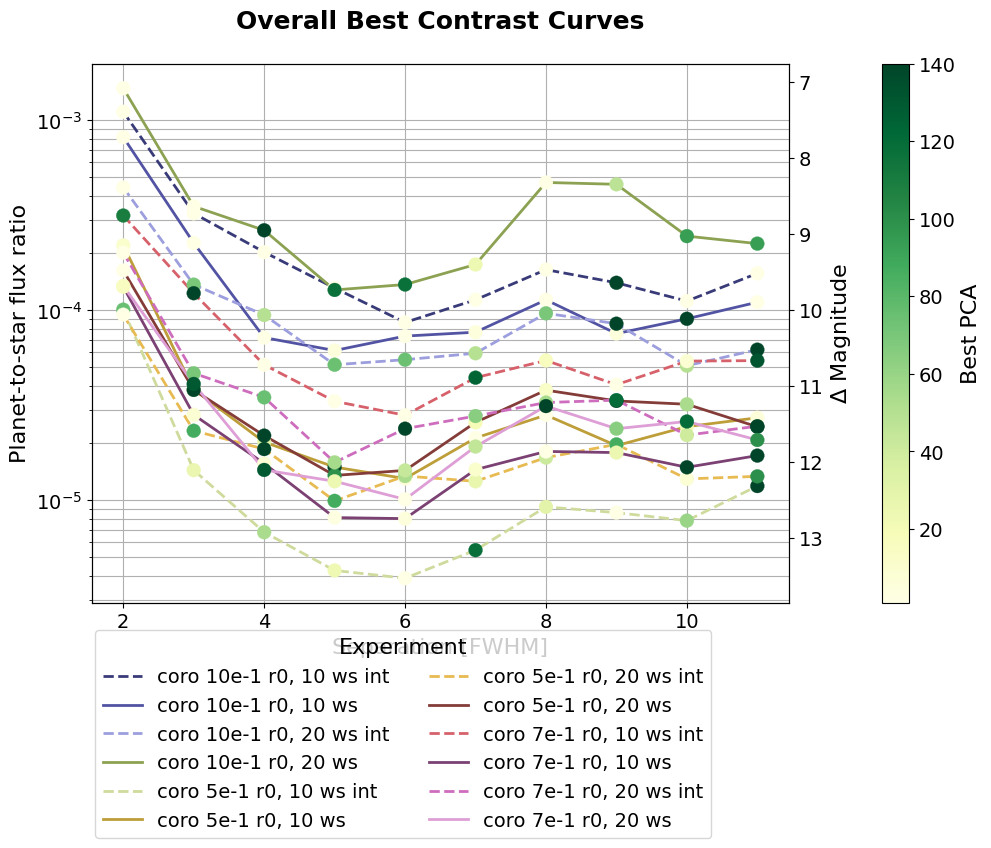

In [35]:
def plot_all_best(curves_output_path):
    with pd.HDFStore(f"{curves_output_path}/overall_best.h5") as store:
        fig, ax = plt.subplots(figsize=(12, 7))
        gs0 = fig.add_gridspec(1, 1)
        # color_map = plt.cm.get_cmap('inferno')   # seaborn-style colormap available in mpl
        # colors = [color_map(int(i)) for i in np.round(np.linspace(0, 250, len(store.keys())))]
        color_map = plt.colormaps["tab20b"]
        colors = color_map(np.linspace(0, 1, len(store)))
        # seq = 'managua'
        # reds = plt.colormaps[seq]
        # blues = plt.colormaps[seq]

        # int_keys = [k for k in store.keys() if k.endswith("int")]
        # pred_keys = [k for k in store.keys() if k.endswith("pred")]

        # red_colors = dict(zip(int_keys, reds(np.linspace(0.2, 1, len(int_keys)))))
        # blue_colors = dict(zip(pred_keys, blues(np.linspace(0.2, 1, len(pred_keys)))))

        # # Then inside the loop:

        # ordered_keys = pred_keys + int_keys

        # df_0 = store[ordered_keys[0]]
        # ax.semilogy(
        #     df_0.index,
        #     df_0["best_contrast"],
        #     lw=1.2,
        #     color = 'black', #colors[i],
        #     ls = '-',
        #     label= 'Predictive Control           ',
        # )
        # ax.semilogy(
        #     df_0.index,
        #     df_0["best_contrast"],
        #     lw=1.5,
        #     color = 'black', #colors[i],
        #     ls = '--',
        #     label= 'Integrator Control             ',
        # )

        for i, key in enumerate(store.keys()):
            df = store[key]

            # line_color = (
            #     red_colors[key] if key.endswith("int")
            #     else blue_colors[key]
            # )

            mark = (
                '--' if key.endswith("int")
                else '-'
            )    

            label =   key.strip("/").replace('_', ' ').replace('windspeed', ' ws').replace('r0', 'e-1 r0,').replace('pred', '')  
            ax.semilogy(
                df.index,
                df["best_contrast"],
                lw=2,
                color = colors[i],
                ls = mark,
                label= label, # if key in pred_keys else None,
            )

            sc = ax.scatter(
                df.index,
                df["best_contrast"],
                c=df["best_PCA"],
                cmap=plt.colormaps["YlGn"],
                s=100,
                zorder=5,
                linewidth = 0.2,
                #edgecolors= line_color, #'grey', #colors[i],
            )

        leg1 = fig.legend(
            fontsize=14,
            loc="lower left",
            bbox_to_anchor=(0.12, -(0.02 * len(store.keys()))),
            ncol=2,
            title="Experiment",
            title_fontsize=16, 
        )
        
    # Colorbar
    cbar = fig.colorbar(
        sc,
        ax=ax,               # or axis_contrast_curves
        pad=0.1,            # distance from the axes
    )

    cbar.set_label(
        "Best PCA",
        fontsize=16,
    )

    cbar.ax.tick_params(labelsize=14)
    ax.set_title(
            'Overall Best Contrast Curves',
            fontsize=18, fontweight="bold", y=1.05)

    ax.set_xlabel("Separation [FWHM]", fontsize=16)
    ax.set_ylabel("Planet-to-star flux ratio", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(which='both')
    ax_mag = ax.twinx()
    ymin, ymax = ax.get_ylim()
    #ax.set_ylim((ymin), (ymax))
    ax_mag.set_ylim(flux_ratio2mag(ymin), flux_ratio2mag(ymax))
    ax_mag.set_ylabel(r"$\Delta$ Magnitude", fontsize=16)
    # ax_mag = ax.secondary_yaxis(
    #     "right",
    #     functions=(flux_ratio2mag, mag2flux_ratio)  # (forward, inverse)
    # )
    ax_mag.tick_params(axis="both", which="major", labelsize=14)

    plt.savefig(f"{(curves_output_path)}/Overall_Best_Contrast.png",
            bbox_inches="tight",
            bbox_extra_artists=(leg1,),
        )

curves_output_path = '/home/aosimul/noah/src/pipeline_ADI/results/contrast'
#curves_output_path = '/home/aosimul/noah/results/animations'
plot_all_best(curves_output_path)

# Download from Chechout Dir

In [ ]:
sc_img_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy")
sc_img_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy")
psf_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_int_0.5ro_10ws.npy")
psf_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_pred_0.5ro_10ws.npy")
dit_psf = 0.5
dit_science = 0.015
print(sc_img_int.shape, sc_img_pred.shape, psf_pred.shape, psf_int.shape)

In [ ]:
def compute_contrast(
        contrast_instance, 
        fwhm, 
        pixel_scale, 
        grid,
        photometry = 'FS', 
        test = 't-test',
        ):
    """
    Compute analytic contrast curves for a processed high-contrast imaging
    dataset using the Appleby tutorial workflow.
    see: https://applefy.readthedocs.io/en/latest/02_user_documentation/01_contrast_curves.html

    The function configures the photometric extraction strategy and
    statistical test, prepares the contrast analysis products, and computes
    contrast curves with associated uncertainties.

    Parameters
    ----------
    contrast_instance : object
        Contrast analysis instance containing the processed dataset and
        fake planet experiment results.
    fwhm : float
        Full width at half maximum (FWHM) of the PSF in pixels.
    photometry : {'FS', 'AS'}, optional
        Photometry extraction method.
        - ``'FS'`` : spaced pixel sampling (default)
        - ``'AS'`` : aperture-sum photometry
    test : {'t-test', 'bootstrap'}, optional
        Statistical test used to estimate detection significance.
        - ``'t-test'`` : assumes Gaussian residual noise (default)
        - ``'bootstrap'`` : Laplacian residual noise model following
          Bonse et al. (2023)
    pixel_scale : float
        Pixel size in arcseconds.
    grid : bool, optional
        If True, compute contrast curves on a grid of separations and flux
        ratios. If False, compute contrast curves at specified separations
        only (default: False).

    Returns
    -------
    if grid is False:
        contrast_curves : object
            Computed analytic contrast curves.
        contrast_errors : object
            Uncertainties associated with the contrast curves.
    if grid is True:
        contrast_curves_grid : dict
            Contrast grids (one for each number of PCA components)
        contrast_grids : pandas DataFrame
            Contrast curves obtained by thresholding the contrast grids.
    
    Warns
    -----
    UserWarning
        Raised if an unsupported photometry mode or statistical test is
        provided.
    """

    if photometry == 'FS':# Use spaced pixel values
        photometry_mode_planet = AperturePhotometryMode(
            "F", # or "P"
            psf_fwhm_radius=fwhm/2,
            search_area=0.5)
        photometry_mode_noise = AperturePhotometryMode(
            "P",
            psf_fwhm_radius=fwhm/2)    
    elif photometry == 'AS': # Use apertures pixel values
        photometry_mode_planet = AperturePhotometryMode(
            "ASS", # or "AS"
            psf_fwhm_radius=fwhm/2,
            search_area=0.5)

        photometry_mode_noise = AperturePhotometryMode(
            "AS",
            psf_fwhm_radius=fwhm/2)
    else:
        # Issue a warning
        warnings.warn("Photometry style not recognized, 'FS' for spaced pixel values and 'AS' for aperture sums.", UserWarning)

    contrast_instance.prepare_contrast_results(
        photometry_mode_planet=photometry_mode_planet,
        photometry_mode_noise=photometry_mode_noise)
    
    if test == 't-test':
        statistical_test = TTest()
    elif test == 'bootstrap':
        #The Parametric Bootstrap test as discussed in (Bonse et al. 2023) (assumes Laplacian residual noise). You can download the lookup from Zenodo.
        statistical_test = LaplaceBootstrapTest.construct_from_json_file("file/to/lookup_table")
    else:
        # Issue a warning
        warnings.warn("Statistical testing style not recognized, 't-test' assumes gaussian residual noise, and 'bootstrap' assumes Laplacian residual noise (you can download the lookup from Zenodo).", UserWarning)

    if grid ==False:
        contrast_curves, contrast_errors = contrast_instance.compute_analytic_contrast_curves(
            statistical_test=statistical_test,
            confidence_level_fpf=gaussian_sigma_2_fpf(5),
            num_rot_iter=20,
            pixel_scale= pixel_scale)

        return contrast_curves, contrast_errors
    
    if grid == True:
        contrast_curves_grid, contrast_grids = contrast_instance.compute_contrast_grids(
            statistical_test=statistical_test,
            confidence_level_fpf=gaussian_sigma_2_fpf(5),
            num_rot_iter=10,
            safety_margin=2.5,
            num_cores=45, 
            pixel_scale= pixel_scale)

        return contrast_curves_grid, contrast_grids

In [ ]:
datasets = {
    "int": {
        "psf"           : psf_int,
        "sci_img"       : sc_img_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science,     #s = 10 phase screens at 0.001s each
    },

    # "pred": {
    #     "psf"           : psf_pred,
    #     "sci_img"       : sc_img_pred,
    #     "fwhm"          : calculate_fwhm(psf_pred),
    #     "dit_psf"       : dit_psf,          #s of integration time
    #     "dit_science"   : dit_science,  
    # },
}

name = 'coro_5r0_10windspeed'
grids = {}

for dataset_name, dataset in datasets.items():
    

    path = f"/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/{name}_{dataset_name}"

        
    contrast_instance = Contrast.create_from_checkpoint_dir(
        psf_template        =dataset["psf"],
        psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
        dit_psf_template    =dataset["dit_psf"], 
        dit_science         =dataset["dit_science"],  # integration time
        checkpoint_dir      =root_dir / Path(path)
        )

    grids[dataset_name] = compute_contrast(
                contrast_instance,
                dataset["fwhm"],
                pixel_scale=None,
                photometry='FS',
                test='t-test',
                grid = True
            )

In [ ]:
rangey = (15,7)
curves_output_path = '/home/aosimul/noah/results/animations'
for dataset_name, dataset in datasets.items():
    result = plot_contrast_curves(grids[dataset_name][0], rangey, curves_output_path, name+'_'+dataset_name, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name}"))
    # result.to_hdf(
    #                     f"{curves_output_path}/overall_best.h5",
    #                     key=name+'_'+dataset_name,
    #                     mode="a"
    #                 )
    plt.show()